In [1]:
import sys
sys.path.insert(0, '/home/lpsha/s154446/fractality')
sys.path.insert(0, '/home/lpsha/s154446/fractality/sierpinski_carpet_model')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import pandas as pd
import importlib
import sierpinski_carpet
importlib.reload(sierpinski_carpet)
from sierpinski_carpet import (
    get_carpet_cells,
    get_carpet_segments,
    get_carpet_geodataframe,
    run_dgdc_on_carpet,
)

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

## 1. Sierpinski carpet geometry

The carpet is built by recursively subdividing the unit square into a 3×3 grid
and removing the centre cell.  After *k* levels, 8^k cells survive out of 9^k.
The boundaries of those cells form the street network.

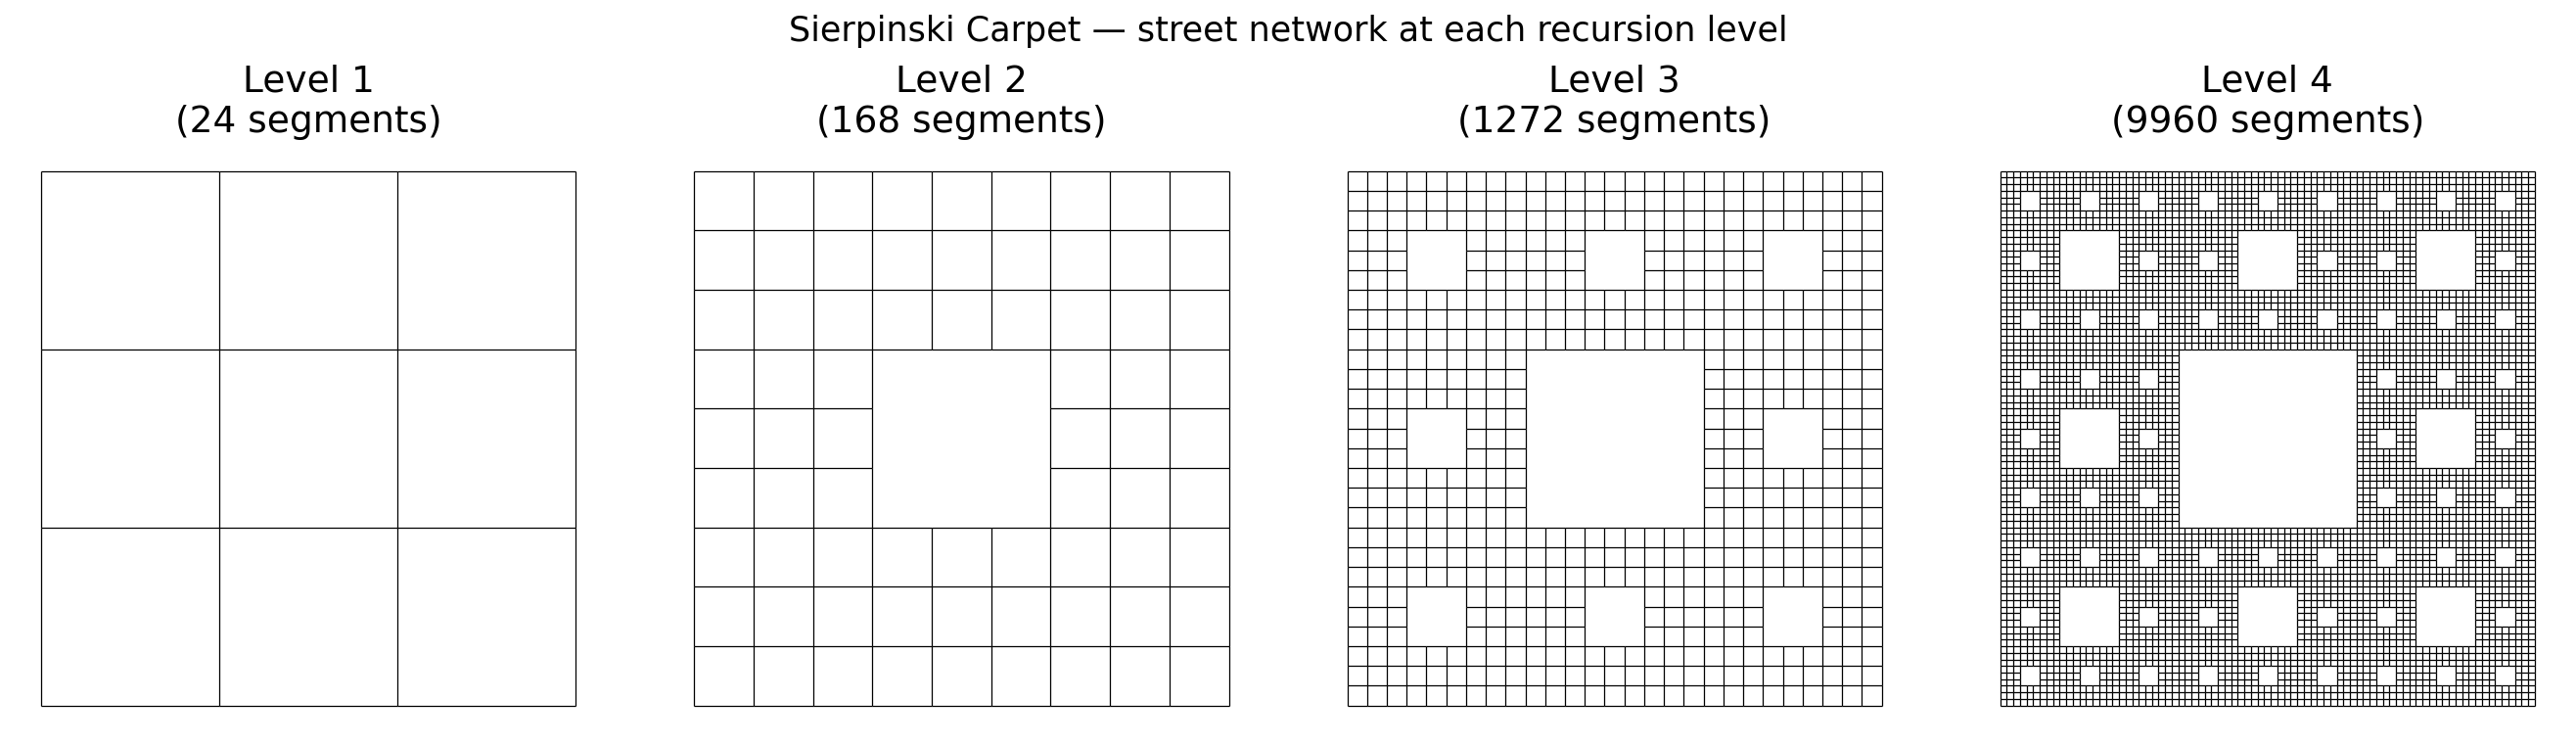

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, level in zip(axes, [1, 2, 3, 4]):
    gdf = get_carpet_geodataframe(level)
    gdf.plot(ax=ax, color='k', linewidth=0.6)
    ax.set_title(f'Level {level}\n({len(gdf)} segments)')
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle('Sierpinski Carpet — street network at each recursion level', y=1.02)
plt.tight_layout()
plt.show()

## 2. Run dgdc on level-3 carpet

`a_threshold=20°` — streets within 20° of each other are merged into a single
directional continuation.  Since all carpet segments are axis-aligned
(horizontal or vertical), segments along the same axis merge into long
"through-streets" that span multiple sub-squares.

In [5]:
gdf_carpet3, gdf_merged3, H3 = run_dgdc_on_carpet(
    level=3, t_buffer=10, a_threshold=20, enforce_degree2=False
)

Building carpet at level 3…
  1272 primal segments
Running dgdc…


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/utils.py:352: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


  101 dual nodes, 656 dual edges


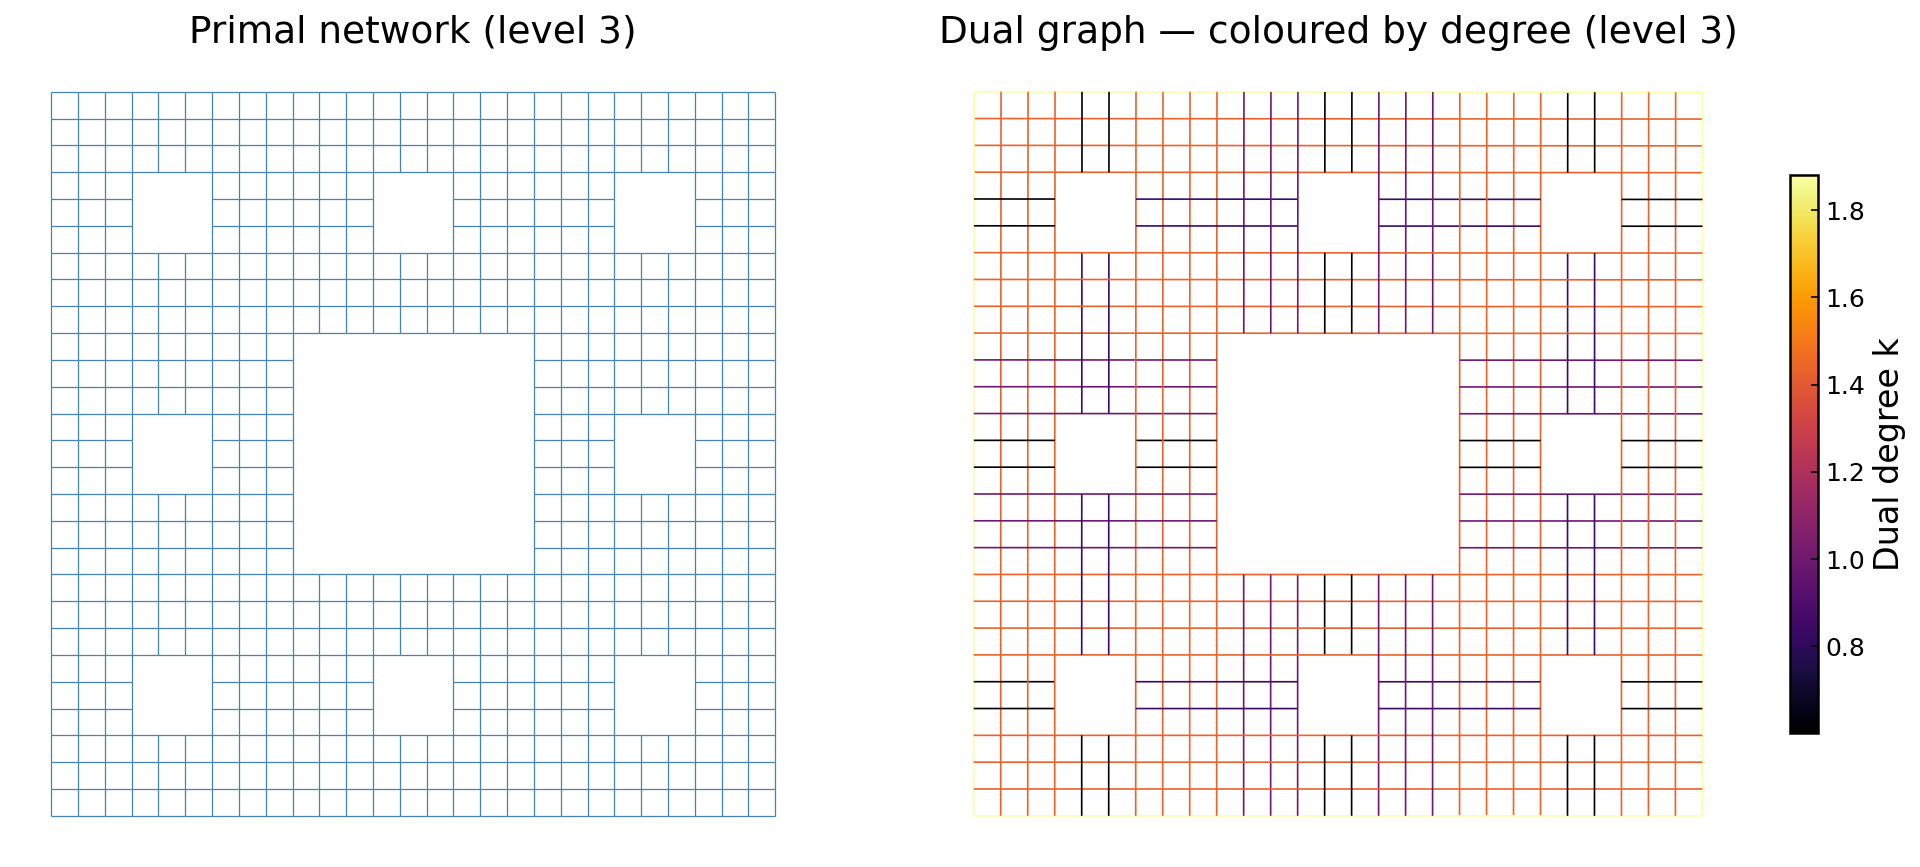

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Primal network (raw carpet segments)
gdf_carpet3.plot(ax=axes[0], color='steelblue', linewidth=0.6)
axes[0].set_title('Primal network (level 3)')
axes[0].set_aspect('equal')
axes[0].axis('off')

# Dual graph coloured by degree
gdf_merged3.plot(ax=axes[1], column='degree_log', cmap='inferno',
                 linewidth=0.8, legend=True,
                 legend_kwds={'label': 'Dual degree k', 'shrink': 0.7})
axes[1].set_title('Dual graph — coloured by degree (level 3)')
axes[1].set_aspect('equal')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
gdf_carpet3, gdf_merged3, H3 = run_dgdc_on_carpet(level=4, t_buffer=10, a_threshold=20, enforce_degree2=False)

Building carpet at level 4…
  9960 primal segments


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/utils.py:352: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


Running dgdc…
  597 dual nodes, 5216 dual edges


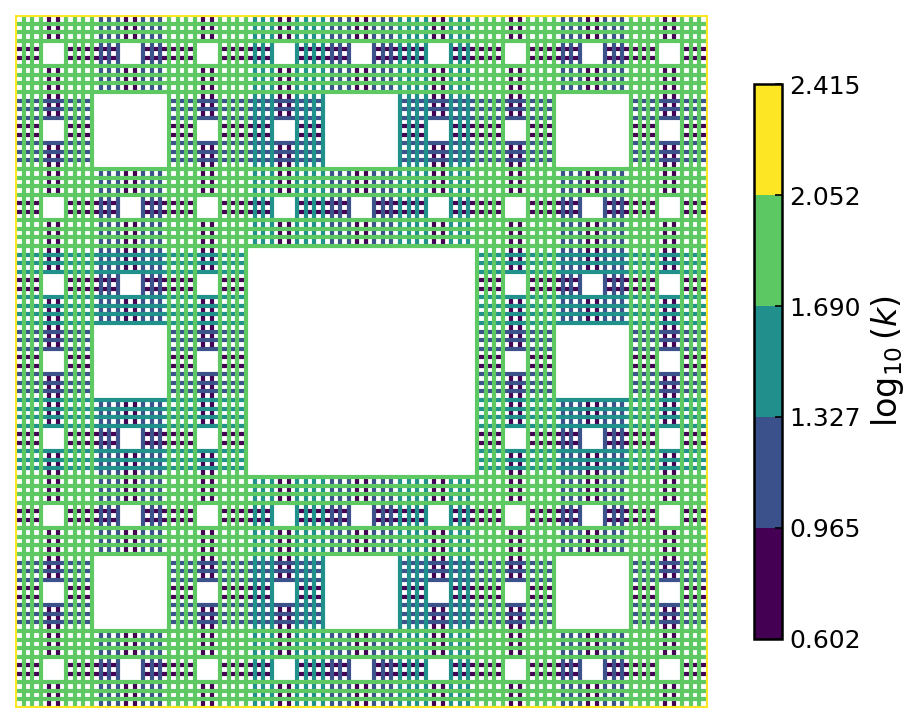

In [15]:
fig, ax = plt.subplots(figsize=(8,6),dpi=150)

n_bins = 5
gdf_sorted = gdf_merged3.to_crs("EPSG:3857").sort_values('degree_log', ascending=True)
gdf_sorted['degree_bin'] = pd.cut(gdf_sorted['degree_log'], bins=n_bins, labels=False)

cmap = plt.cm.viridis
norm = mcolors.BoundaryNorm(boundaries=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1),ncolors=cmap.N)

for b in range(n_bins):
    subset = gdf_sorted[gdf_sorted['degree_bin'] == b]
    subset.plot(ax=ax, color=cmap(b / (n_bins - 1)), linewidth=2)

# Binned colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.8, spacing='proportional', ticks=np.linspace(gdf_sorted['degree_log'].min(), gdf_sorted['degree_log'].max(), n_bins + 1))
cbar.set_label(r'$\log_{10}(k)$')

# Limit axes to data extent
minx, miny, maxx, maxy = gdf_sorted.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.axis('off')
plt.show()

## 3. Compare levels 2, 3, 4

In [7]:
results = {}
for level in [2, 3, 4]:
    gdf_c, gdf_m, H = run_dgdc_on_carpet(level=level, t_buffer=1, a_threshold=20)
    results[level] = (gdf_c, gdf_m, H)
    print(f"Level {level}: {len(gdf_c)} primal segs → {H.number_of_nodes()} dual nodes")

Building carpet at level 2…
  168 primal segments
Running dgdc…


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/utils.py:352: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


  21 dual nodes, 80 dual edges
Level 2: 168 primal segs → 21 dual nodes
Building carpet at level 3…
  1272 primal segments
Running dgdc…


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/utils.py:352: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


  101 dual nodes, 656 dual edges
Level 3: 1272 primal segs → 101 dual nodes
Building carpet at level 4…
  9960 primal segments


/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/momepy/utils.py:352: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


Running dgdc…
  597 dual nodes, 5216 dual edges
Level 4: 9960 primal segs → 597 dual nodes


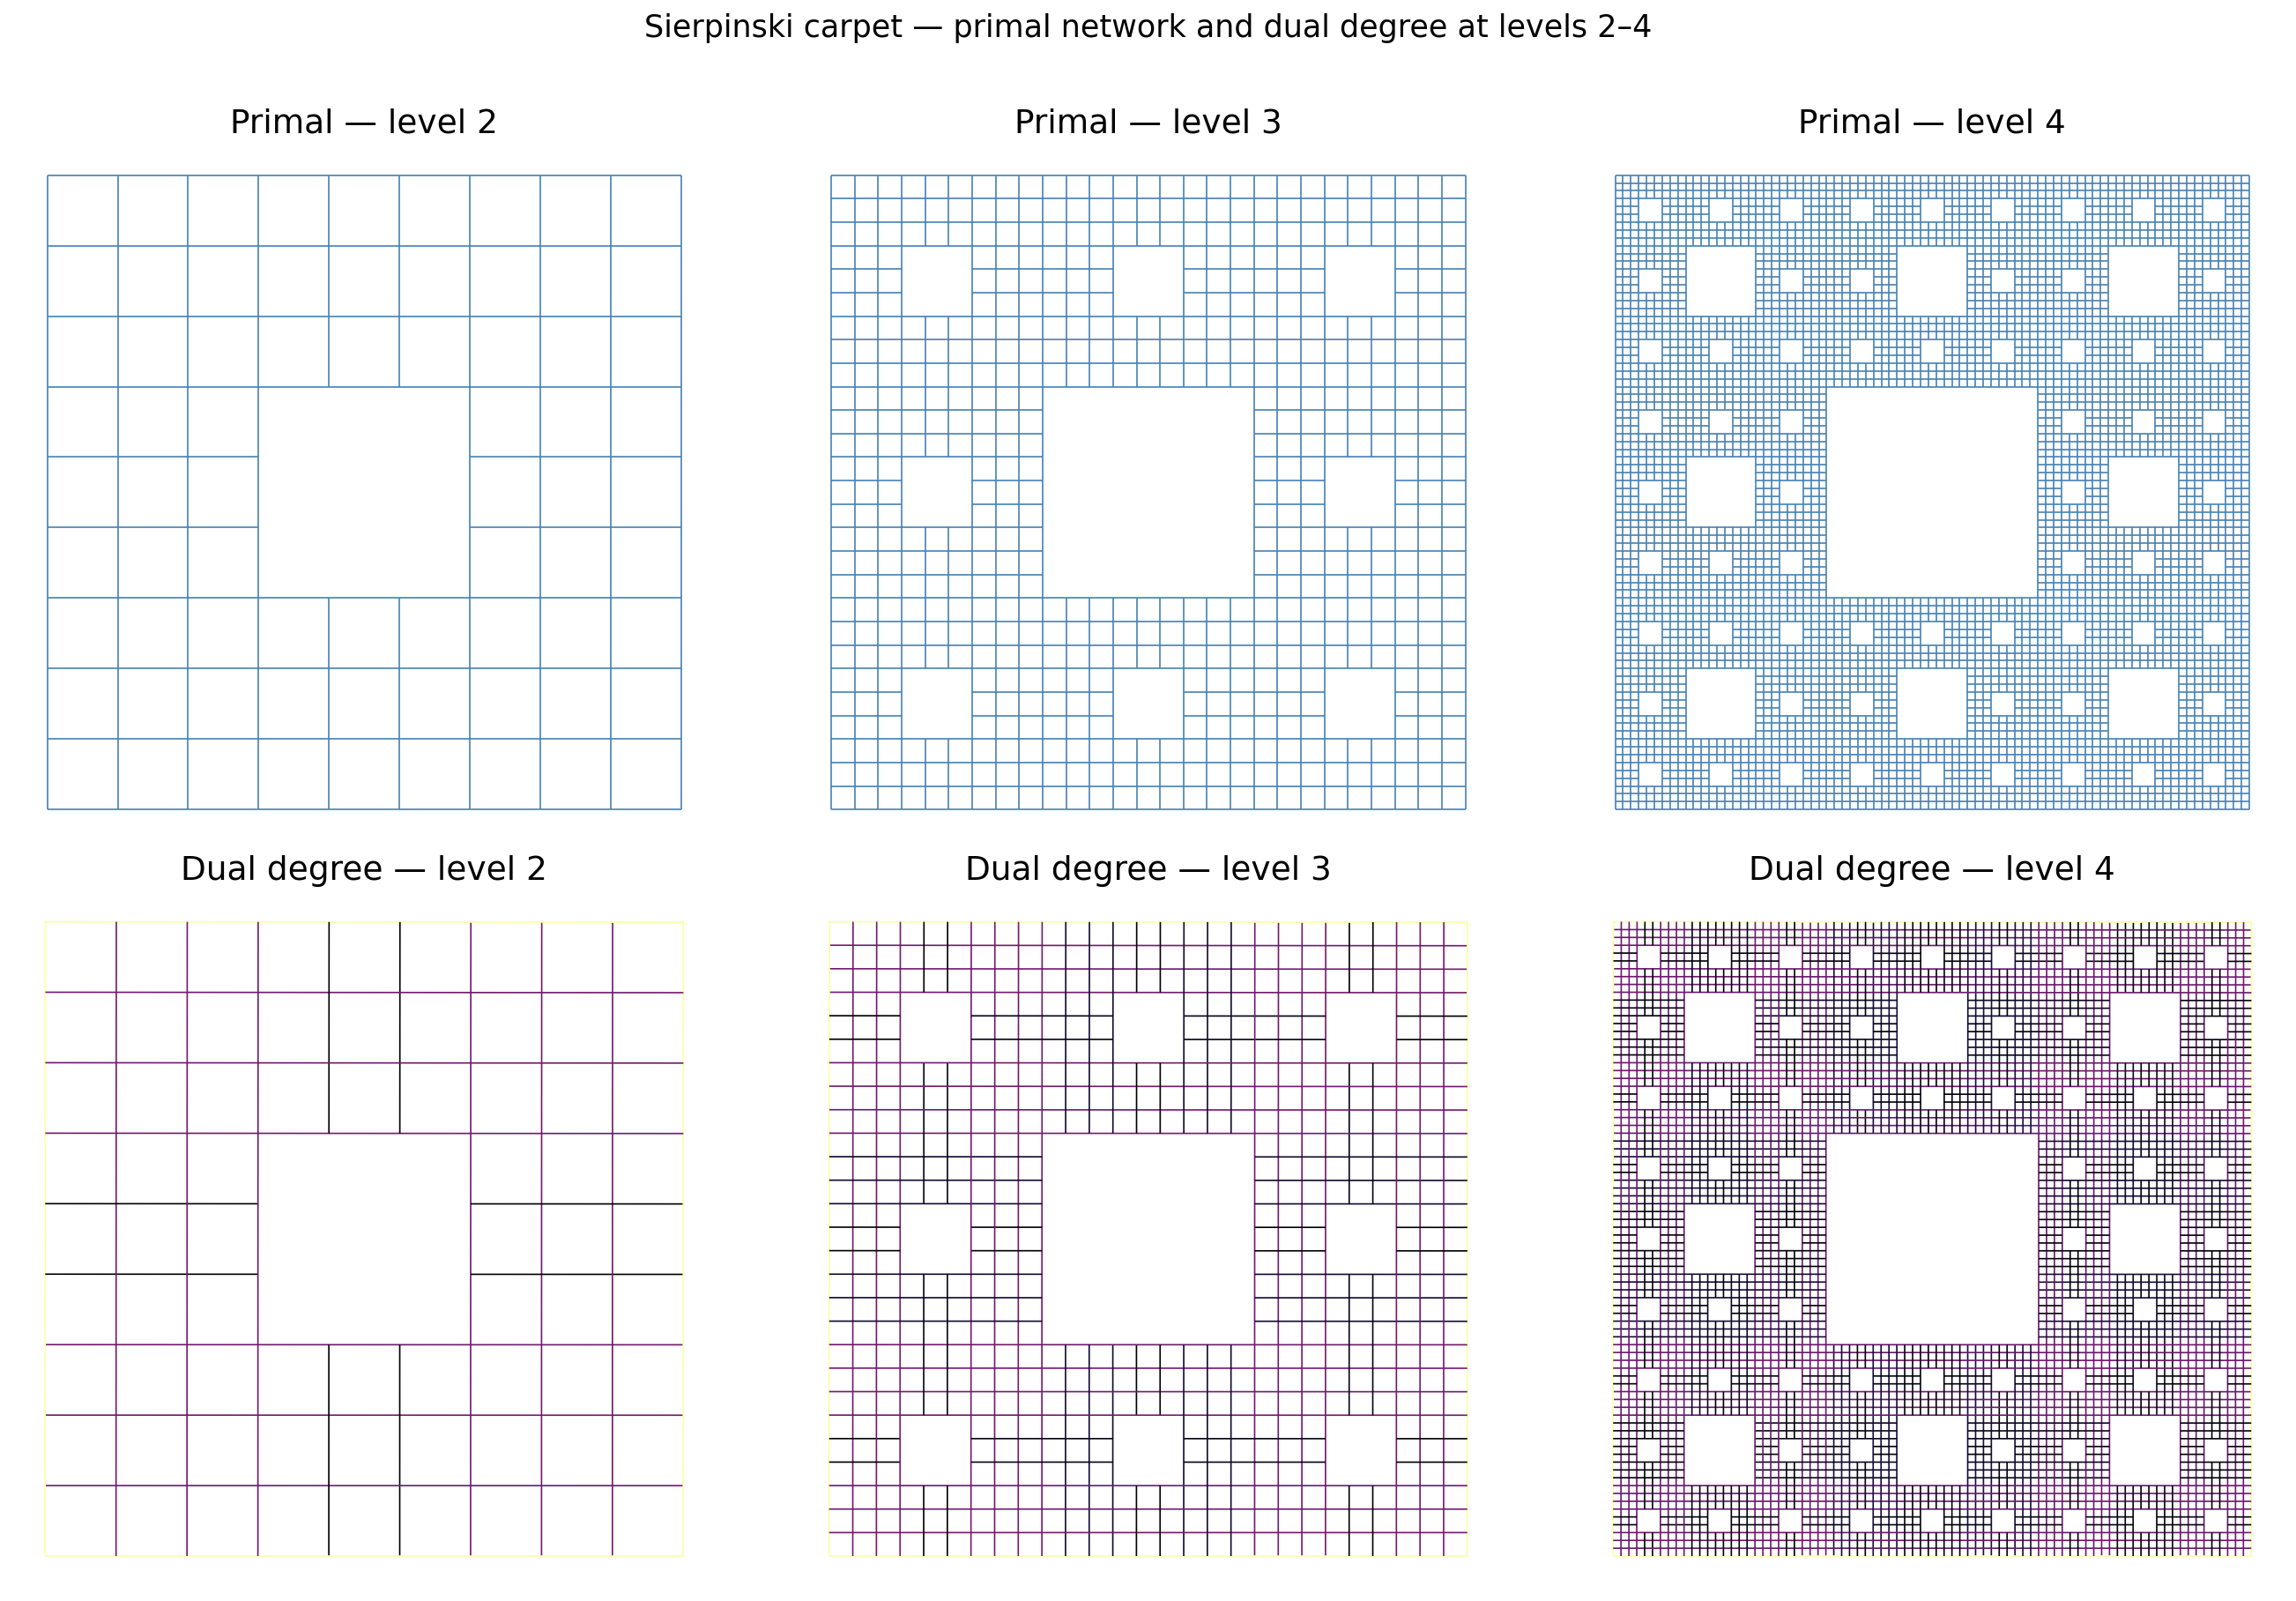

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col, level in enumerate([2, 3, 4]):
    gdf_c, gdf_m, H = results[level]

    gdf_c.plot(ax=axes[0, col], color='steelblue', linewidth=0.8)
    axes[0, col].set_title(f'Primal — level {level}')
    axes[0, col].set_aspect('equal')
    axes[0, col].axis('off')

    gdf_m.plot(ax=axes[1, col], column='degree', cmap='inferno',
               linewidth=0.8, legend=False)
    axes[1, col].set_title(f'Dual degree — level {level}')
    axes[1, col].set_aspect('equal')
    axes[1, col].axis('off')

plt.suptitle('Sierpinski carpet — primal network and dual degree at levels 2–4', y=1.01)
plt.tight_layout()
plt.show()

## 4. Degree distributions

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, level in zip(axes, [2, 3, 4]):
    _, gdf_m, _ = results[level]
    deg = gdf_m['degree'].values
    deg = deg[deg > 0]

    unique_deg = np.unique(deg)
    counts = np.array([np.sum(deg == d) for d in unique_deg])
    prob = counts / counts.sum()

    ax.scatter(unique_deg, prob, color='k', s=30, zorder=3)
    ax.plot(unique_deg, prob, color='crimson', linewidth=1.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('k')
    ax.set_ylabel('p(k)')
    ax.set_title(f'Level {level} — degree distribution')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.suptitle('Dual graph degree distributions', y=1.02)
plt.tight_layout()
plt.show()

## 5. Effect of angle threshold

The carpet has only 0° and 90° angles.  With `a_threshold < 90°`, only
collinear segments (0°) are merged — producing straight through-streets.
Setting `a_threshold ≥ 90°` would also merge perpendicular streets.

In [ ]:
thresholds = [5, 20, 45, 89]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, thresh in enumerate(thresholds):
    _, gdf_m, H = run_dgdc_on_carpet(level=3, t_buffer=1, a_threshold=thresh)

    gdf_m.plot(ax=axes[0, col], color='steelblue', linewidth=0.7)
    axes[0, col].set_title(f'a_threshold = {thresh}°\n{H.number_of_nodes()} dual nodes')
    axes[0, col].set_aspect('equal')
    axes[0, col].axis('off')

    deg = gdf_m['degree'].values
    deg = deg[deg > 0]
    unique_deg = np.unique(deg)
    counts = np.array([np.sum(deg == d) for d in unique_deg])
    prob = counts / counts.sum()
    axes[1, col].scatter(unique_deg, prob, color='k', s=20)
    axes[1, col].plot(unique_deg, prob, color='crimson')
    axes[1, col].set_xscale('log')
    axes[1, col].set_yscale('log')
    axes[1, col].set_xlabel('k')
    axes[1, col].set_ylabel('p(k)')
    axes[1, col].spines['right'].set_visible(False)
    axes[1, col].spines['top'].set_visible(False)

plt.suptitle('Level-3 carpet — effect of angle threshold on dual graph', y=1.01)
plt.tight_layout()
plt.show()

## 6. Degree statistics vs. recursion level

In [ ]:
levels = [1, 2, 3, 4]
stats = []
for level in levels:
    _, gdf_m, H = run_dgdc_on_carpet(level=level, t_buffer=1, a_threshold=20)
    deg = gdf_m['degree'].values
    stats.append({
        'level': level,
        'n_dual_nodes': H.number_of_nodes(),
        'mean_degree': deg.mean(),
        'max_degree': deg.max(),
        'median_degree': np.median(deg),
    })

df_stats = pd.DataFrame(stats)
print(df_stats.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(df_stats['level'], df_stats['n_dual_nodes'], 'o-', color='k')
axes[0].set_xlabel('Recursion level')
axes[0].set_ylabel('Number of dual nodes')
axes[0].set_title('Dual graph size vs. recursion level')
axes[0].set_yscale('log')
axes[0].spines['right'].set_visible(False)
axes[0].spines['top'].set_visible(False)

axes[1].plot(df_stats['level'], df_stats['max_degree'], 's-', color='crimson', label='max')
axes[1].plot(df_stats['level'], df_stats['mean_degree'], 'o-', color='steelblue', label='mean')
axes[1].plot(df_stats['level'], df_stats['median_degree'], '^-', color='k', label='median')
axes[1].set_xlabel('Recursion level')
axes[1].set_ylabel('Degree')
axes[1].set_title('Dual degree statistics vs. recursion level')
axes[1].legend()
axes[1].spines['right'].set_visible(False)
axes[1].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()